# 15. Stage 1 LLM Evaluation

SSAFY GMS의 `gpt-5.4-nano`가 사용자 자연어를 Stage 1 구조로 변환하는 성능을 동일 Golden Set 200개에서 Current Rule·Extended Rule과 비교한다.

원칙: LLM은 향수를 추천하거나 Ranking하지 않는다. Golden label, Rule 예측, Extended Rule 예측은 Prompt에 전달하지 않는다. 고정된 zero-shot 지시문 하나만 사용한다.


## 0. 실험 목적 및 원칙

- 평가 대상: 자연어 → Stage 1 구조화
- 비교 대상: Current Rule / Extended Rule / LLM
- 함께 측정: 정확도, API 안정성, 지연시간, 실제 응답에 포함된 Token Usage
- 금지: Golden label 기반 Prompt 튜닝, 의미 유사도 수동 판정, 실패 예측 임의 보정, 비용 단가 추정
- 실패 Query 정책: 원 실패 상태는 보존하고, 전체 200개 평가에만 빈 Stage 1 구조로 포함한다.


## 1. Environment & Imports


In [1]:
import collections
import hashlib
import json
import math
import os
import pathlib
import re
import statistics
import time
from datetime import datetime, timezone

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from IPython.display import Markdown, display

try:
    from dotenv import load_dotenv
except ImportError as exc:
    raise ImportError("python-dotenv가 필요합니다. 현재 Kernel 환경에 설치한 뒤 다시 실행하세요.") from exc

pd.set_option("display.max_colwidth", 160)
pd.set_option("display.max_columns", 60)


## 2. Path / Configuration


In [2]:
PROJECT_ROOT = pathlib.Path.cwd().resolve()
OUTPUT_DIR = PROJECT_ROOT / "analysis_outputs"
GOLDSET_PATH = PROJECT_ROOT / "evaluation_data" / "stage1" / "13_stage1_golden_set_v1_200.xlsx"
CURRENT_METRICS_PATH = OUTPUT_DIR / "13_rule_stage1_metrics.csv"
EXTENDED_METRICS_PATH = OUTPUT_DIR / "14_extended_rule_stage1_metrics.csv"
RULE_COMPARISON_PATH = OUTPUT_DIR / "14_rule_comparison.csv"
CURRENT_EVALUATION_PATH = OUTPUT_DIR / "13_rule_stage1_evaluation.csv"
EXTENDED_EVALUATION_PATH = OUTPUT_DIR / "14_extended_rule_stage1_evaluation.csv"

NOTEBOOK_13_PATH = PROJECT_ROOT / "13_stage1_rule_baseline_evaluation.ipynb"
NOTEBOOK_14_PATH = PROJECT_ROOT / "14_stage1_extended_rule_evaluation.ipynb"

CHECKPOINT_PATH = OUTPUT_DIR / "15_llm_stage1_checkpoint.csv"
PREDICTIONS_PATH = OUTPUT_DIR / "15_llm_stage1_predictions.csv"
EVALUATION_PATH = OUTPUT_DIR / "15_llm_stage1_evaluation.csv"
ERRORS_PATH = OUTPUT_DIR / "15_llm_stage1_errors.csv"
METRICS_PATH = OUTPUT_DIR / "15_llm_stage1_metrics.csv"
API_METRICS_PATH = OUTPUT_DIR / "15_llm_api_metrics.csv"
MODEL_COMPARISON_PATH = OUTPUT_DIR / "15_stage1_model_comparison.csv"
ERROR_COMPARISON_PATH = OUTPUT_DIR / "15_error_comparison.csv"
QUERY_CHANGES_PATH = OUTPUT_DIR / "15_llm_vs_extended_query_changes.csv"
PROMPT_PATH = OUTPUT_DIR / "15_stage1_llm_prompt_v1.txt"
SUMMARY_PATH = OUTPUT_DIR / "15_llm_stage1_summary.md"

MODEL_NAME = "gpt-5.4-nano"
GMS_ENDPOINT = "https://gms.ssafy.io/gmsapi/api.openai.com/v1/chat/completions"
PROMPT_VERSION = "stage1_llm_v1"
RUN_TIMESTAMP = datetime.now(timezone.utc).astimezone().isoformat(timespec="seconds")
FORCE_RERUN = False
MAX_RETRIES = 2
MAX_ATTEMPTS = 1 + MAX_RETRIES
REQUEST_TIMEOUT_SECONDS = 90
COST_PER_INPUT_TOKEN = None
COST_PER_OUTPUT_TOKEN = None

PROTECTED_PATHS = {
    "13 notebook": NOTEBOOK_13_PATH,
    "14 notebook": NOTEBOOK_14_PATH,
    "Golden Set": GOLDSET_PATH,
    "13 metrics": CURRENT_METRICS_PATH,
    "14 metrics": EXTENDED_METRICS_PATH,
    "14 comparison": RULE_COMPARISON_PATH,
    "13 evaluation": CURRENT_EVALUATION_PATH,
    "14 evaluation": EXTENDED_EVALUATION_PATH,
}
for label, path in PROTECTED_PATHS.items():
    if not path.is_file():
        raise FileNotFoundError(f"필수 파일이 없습니다 - {label}: {path}")

def sha256_file(path):
    digest = hashlib.sha256()
    with path.open("rb") as file:
        for chunk in iter(lambda: file.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

protected_hashes_before = {label: sha256_file(path) for label, path in PROTECTED_PATHS.items()}
OUTPUT_DIR.mkdir(exist_ok=True)
display(pd.DataFrame([{"label": k, "path": str(v), "sha256": protected_hashes_before[k]} for k, v in PROTECTED_PATHS.items()]))


,label,path,sha256
0,13 notebook,C:\Users\SSAFY\Desktop\EDA\13_stage1_rule_baseline_evaluation.ipynb,551a1602d4b29c81f388644330038139940eb484c0275bffec1fd5d8fd71b670
1,14 notebook,C:\Users\SSAFY\Desktop\EDA\14_stage1_extended_rule_evaluation.ipynb,38012bfa38815ad200c7b131184de340fafd3868b2c212e0e0c9892f74bff670
2,Golden Set,C:\Users\SSAFY\Desktop\EDA\evaluation_data\stage1\13_stage1_golden_set_v1_200.xlsx,a56613ad4bb082d2a05408f0a888727945cbc924a33ca064140a5c565589c3df
3,13 metrics,C:\Users\SSAFY\Desktop\EDA\analysis_outputs\13_rule_stage1_metrics.csv,9be6362c31aade22b6b75cbc95d2a14f855adc3978010eb9fa04468332092cfc
4,14 metrics,C:\Users\SSAFY\Desktop\EDA\analysis_outputs\14_extended_rule_stage1_metrics.csv,4bf0f63b4c957391f6ff875a731e59bb517b335a6e7ed87861df0125016b8a1d
5,14 comparison,C:\Users\SSAFY\Desktop\EDA\analysis_outputs\14_rule_comparison.csv,0aa07577d8817c4403f25127db5dbfcb62cf5acbc29371d969c6195a8810a04f
6,13 evaluation,C:\Users\SSAFY\Desktop\EDA\analysis_outputs\13_rule_stage1_evaluation.csv,5c94d2a504d00eb4f599062eb7c09c145484d36fc843dc425e43cf774b1ef660
7,14 evaluation,C:\Users\SSAFY\Desktop\EDA\analysis_outputs\14_extended_rule_stage1_evaluation.csv,94e044d4e30b69a6d8b5e8e5e88dfaf5df45e3310198b25e1901fa6579a29006


## 3. Load Environment Variables

`.env`에서 `GMS_KEY`를 읽되 존재 여부만 출력한다. Key 값과 Authorization header는 어떤 출력이나 파일에도 저장하지 않는다.


In [3]:
load_dotenv(PROJECT_ROOT / ".env")
GMS_KEY = os.getenv("GMS_KEY")
print("GMS_KEY present:", bool(GMS_KEY))
if not GMS_KEY:
    raise RuntimeError("프로젝트 루트 .env에서 GMS_KEY를 찾지 못했습니다.")


GMS_KEY present: True


## 4. Define Stage 1 Schema & Prompt

Prompt는 모든 Query에서 동일하며 평가 정답이나 Rule 예측을 포함하지 않는다. 공식 OpenAI Chat Completions 문서가 설명하는 `developer`·`user` 메시지 구조만 사용하고, GMS 전용 추가 기능은 가정하지 않는다.


In [4]:
EMPTY_STAGE1 = {
    "scent_preference": [],
    "context": {"season": [], "daypart": [], "gender": []},
    "performance": {"intensity": "", "longevity": ""},
    "avoid": [],
    "additional_requirements": [],
}
ALLOWED_CATEGORIES = {
    "season": {"spring", "summer", "autumn", "winter"},
    "daypart": {"day", "night"},
    "gender": {"male", "female", "neuter"},
    "intensity": {"", "LOW", "MEDIUM", "HIGH"},
    "longevity": {"", "LOW", "MEDIUM", "HIGH"},
}

STAGE1_DEVELOPER_PROMPT = r"""
당신은 향수 추천 요청의 Stage 1 자연어 구조화기입니다. 향수를 추천하거나 순위를 매기지 마세요.
반드시 설명, 주석, Markdown 없이 아래 key를 정확히 가진 JSON object 하나만 반환하세요.

{
  "scent_preference": [],
  "context": {"season": [], "daypart": [], "gender": []},
  "performance": {"intensity": "", "longevity": ""},
  "avoid": [],
  "additional_requirements": []
}

필드 규칙:
- scent_preference: 사용자가 직접 선호한다고 말한 명시적 Note/Accord 향만 배열에 기록합니다. 가능한 경우 일반적인 영어 canonical 표기(예: Vanilla, Rose, Mint, Coconut, citrus, woody)를 사용합니다. 확신할 수 없는 새 향 이름을 만들지 마세요.
- context.season: spring, summer, autumn, winter만 허용합니다.
- context.daypart: day, night만 허용합니다.
- context.gender: 사용자가 원하는 향수의 성별 인식/타깃이 명시된 경우에만 male, female, neuter를 사용합니다. 단순 자기소개는 문맥상 향수 조건이 아닐 수 있습니다.
- performance.intensity: 명시적 강도 요구만 LOW, MEDIUM, HIGH로 기록하고 없으면 빈 문자열입니다.
- performance.longevity: 명시적 지속력 요구만 LOW, MEDIUM, HIGH로 기록하고 없으면 빈 문자열입니다.
- avoid: 사용자가 명시적으로 싫어하거나 피하려는 대상만 짧게 보존합니다. 긍정 대상과 부정 범위를 구분하세요.
- additional_requirements: 위 핵심 Feature로 직접 구조화할 수 없는 감성, 장면, 상황, 나이, 가격 및 기타 요구를 의미를 잃지 않게 짧게 보존합니다.

중요한 해석 제한:
- 사용자가 직접 말한 의미만 구조화합니다. 향수 전문가 지식으로 암시를 Note, Accord, Gender, Intensity, Longevity로 확장하지 마세요.
- 이미지/감각 표현(깨끗한, 포근한, 차가운, 고급스러운, 도시적인 등)을 임의의 향으로 바꾸지 마세요.
- 장면이나 직업(비 오는 숲, 고급 호텔, 소개팅, 금융맨 등)을 임의의 향·성별·성능으로 바꾸지 마세요.
- 두통이 없기를 바라는 표현을 자동으로 LOW intensity로 바꾸지 마세요.
- 핵심 Feature로 확신할 수 없는 원문 의미는 additional_requirements에 보존하세요.
- 입력에 없는 조건을 추가하지 마세요.
- 배열에는 문자열만 넣고 중복을 제거하세요.
""".strip()

def build_user_prompt(query_text):
    return f"아래 사용자 향수 추천 요청을 Stage 1 Schema로 구조화하세요.\n\n사용자 요청:\n{query_text}"

PROMPT_PATH.write_text(STAGE1_DEVELOPER_PROMPT, encoding="utf-8")
print("Prompt version:", PROMPT_VERSION)
print("Prompt SHA256:", hashlib.sha256(STAGE1_DEVELOPER_PROMPT.encode("utf-8")).hexdigest())


Prompt version: stage1_llm_v1
Prompt SHA256: 4f0a368d98b413384935d4bb54d36d19b60895904d16733d526a1a82737cc493


## 5. GMS Client Function

요청 payload는 Smoke Test에서 지원 여부를 알 수 없는 옵션을 넣지 않고 `model`, `messages`만 사용한다.


In [5]:
def extract_usage(response_json):
    usage = response_json.get("usage") if isinstance(response_json, dict) else None
    if not isinstance(usage, dict):
        return {"prompt_tokens": np.nan, "completion_tokens": np.nan, "total_tokens": np.nan, "usage_keys": []}
    return {
        "prompt_tokens": usage.get("prompt_tokens", usage.get("input_tokens", np.nan)),
        "completion_tokens": usage.get("completion_tokens", usage.get("output_tokens", np.nan)),
        "total_tokens": usage.get("total_tokens", np.nan),
        "usage_keys": sorted(usage.keys()),
    }

def call_gms(query_text):
    payload = {
        "model": MODEL_NAME,
        "messages": [
            {"role": "developer", "content": STAGE1_DEVELOPER_PROMPT},
            {"role": "user", "content": build_user_prompt(query_text)},
        ],
    }
    headers = {"Authorization": f"Bearer {GMS_KEY}", "Content-Type": "application/json"}
    started = time.perf_counter()
    try:
        response = requests.post(GMS_ENDPOINT, headers=headers, json=payload, timeout=REQUEST_TIMEOUT_SECONDS)
        latency = time.perf_counter() - started
        raw_http_text = response.text
        try:
            response_json = response.json()
        except ValueError:
            response_json = None
        return {
            "http_status": response.status_code,
            "latency_seconds": latency,
            "response_json": response_json,
            "raw_http_text": raw_http_text,
            "request_exception": "",
        }
    except requests.RequestException as exc:
        return {
            "http_status": np.nan,
            "latency_seconds": time.perf_counter() - started,
            "response_json": None,
            "raw_http_text": "",
            "request_exception": f"{type(exc).__name__}: {exc}",
        }


## 6. Smoke Test

Golden Set을 로드하기 전에 독립 문장 1개로 연결과 기본 응답 구조를 확인한다. 실패하면 예외를 발생시켜 200개 평가를 시작하지 않는다.


In [6]:
SMOKE_QUERY = "바닐라 향이 나는 향수를 찾고 있어"
smoke_result = call_gms(SMOKE_QUERY)
smoke_json = smoke_result["response_json"]
smoke_checks = {
    "http_status": smoke_result["http_status"],
    "response_is_json_object": isinstance(smoke_json, dict),
    "choices_exists": isinstance(smoke_json, dict) and isinstance(smoke_json.get("choices"), list) and bool(smoke_json.get("choices")),
    "message_content_exists": False,
    "usage_exists": isinstance(smoke_json, dict) and isinstance(smoke_json.get("usage"), dict),
    "latency_seconds": smoke_result["latency_seconds"],
}
if smoke_checks["choices_exists"]:
    choice0 = smoke_json["choices"][0]
    smoke_checks["message_content_exists"] = (
        isinstance(choice0, dict) and isinstance(choice0.get("message"), dict)
        and isinstance(choice0["message"].get("content"), str)
    )
display(pd.DataFrame([smoke_checks]))
if smoke_result["request_exception"]:
    raise RuntimeError(f"Smoke Test request 실패: {smoke_result['request_exception']}")
if not isinstance(smoke_result["http_status"], (int, np.integer)) or not (200 <= smoke_result["http_status"] < 300):
    safe_error = smoke_json if isinstance(smoke_json, dict) else smoke_result["raw_http_text"][:500]
    raise RuntimeError(f"Smoke Test HTTP 실패: status={smoke_result['http_status']}, response={safe_error}")
if not smoke_checks["message_content_exists"]:
    raise RuntimeError("Smoke Test 응답에 choices[0].message.content가 없습니다.")
print("Smoke Test passed.")


,http_status,response_is_json_object,choices_exists,message_content_exists,usage_exists,latency_seconds
0,200,True,True,True,True,3.292346


Smoke Test passed.


## 7. Inspect GMS Response Structure

응답 내용 자체나 인증정보는 출력하지 않고 key 구조와 usage 제공 여부만 확인한다.


In [7]:
smoke_usage = extract_usage(smoke_json)
structure_report = {
    "top_level_keys": sorted(smoke_json.keys()),
    "choice_keys": sorted(smoke_json["choices"][0].keys()),
    "message_keys": sorted(smoke_json["choices"][0]["message"].keys()),
    "usage_present": smoke_checks["usage_exists"],
    "usage_keys": smoke_usage["usage_keys"],
    "prompt_tokens_present": not pd.isna(smoke_usage["prompt_tokens"]),
    "completion_tokens_present": not pd.isna(smoke_usage["completion_tokens"]),
    "total_tokens_present": not pd.isna(smoke_usage["total_tokens"]),
}
display(pd.DataFrame([structure_report]))


,top_level_keys,choice_keys,message_keys,usage_present,usage_keys,prompt_tokens_present,completion_tokens_present,total_tokens_present
0,"[choices, created, id, model, object, service_tier, system_fingerprint, usage]","[finish_reason, index, message]","[annotations, content, refusal, role]",True,"[completion_tokens, completion_tokens_details, prompt_tokens, prompt_tokens_details, total_tokens]",True,True,True


## 8. Load & Validate Golden Set

이 시점까지 Golden Set은 API Prompt 구성이나 Smoke Test에 사용되지 않았다. 이후에도 gold 값은 평가 함수에만 전달한다.


In [8]:
JSON_COLUMNS = ["gold_scent_preference", "gold_context", "gold_performance", "gold_avoid", "gold_additional_requirements"]
EXPECTED_COLUMNS = ["query_id", "query_text", *JSON_COLUMNS]

def load_goldset(path=GOLDSET_PATH):
    return pd.read_excel(path, sheet_name="Golden Set", header=4, dtype=str, keep_default_na=False)

def parse_json_cell(value, query_id, column):
    try:
        return json.loads(value)
    except (TypeError, json.JSONDecodeError) as exc:
        raise ValueError(f"JSON parsing 실패: query_id={query_id}, column={column}") from exc

def validate_goldset(frame):
    if frame.columns.tolist() != EXPECTED_COLUMNS:
        raise ValueError(f"Golden Set 컬럼 불일치: {frame.columns.tolist()}")
    if len(frame) != 200:
        raise ValueError(f"Golden Set은 200개여야 합니다: {len(frame)}")
    if frame["query_id"].duplicated().any() or frame["query_text"].duplicated().any():
        raise ValueError("query_id 또는 query_text가 중복됩니다.")
    parsed = frame.copy()
    for column in JSON_COLUMNS:
        parsed[column] = [parse_json_cell(v, q, column) for v, q in zip(frame[column], frame["query_id"])]
    for row in parsed.itertuples(index=False):
        if not isinstance(row.gold_scent_preference, list): raise TypeError(f"{row.query_id}: scent는 list여야 합니다.")
        if set(row.gold_context) != {"season", "daypart", "gender"}: raise ValueError(f"{row.query_id}: context key 불일치")
        if set(row.gold_performance) != {"intensity", "longevity"}: raise ValueError(f"{row.query_id}: performance key 불일치")
        if not isinstance(row.gold_avoid, list) or not isinstance(row.gold_additional_requirements, list):
            raise TypeError(f"{row.query_id}: avoid/additional은 list여야 합니다.")
    return parsed

gold_df = validate_goldset(load_goldset())
print(f"Golden Set Query count: {len(gold_df)}")


Golden Set Query count: 200


## 9. Load Current / Extended Metrics


In [9]:
def load_metric_series(path):
    frame = pd.read_csv(path)
    if frame.columns.tolist() != ["metric", "value"] or frame["metric"].duplicated().any():
        raise ValueError(f"Metric 파일 스키마 오류: {path}")
    return frame, frame.set_index("metric")["value"]

current_metrics_df, current_metric = load_metric_series(CURRENT_METRICS_PATH)
extended_metrics_df, extended_metric = load_metric_series(EXTENDED_METRICS_PATH)
rule_comparison_df = pd.read_csv(RULE_COMPARISON_PATH)
display(pd.DataFrame({
    "current_rule": current_metric.reindex(["overall_exact_match", "any_condition_prediction_coverage", "positive_scent_micro_f1"]),
    "extended_rule": extended_metric.reindex(["overall_exact_match", "any_condition_prediction_coverage", "positive_scent_micro_f1"]),
}))


,current_rule,extended_rule
metric,,
overall_exact_match,0.015000,0.04500
any_condition_prediction_coverage,0.155000,0.33000
positive_scent_micro_f1,0.459016,0.53125


## 10. LLM Response Parser


In [10]:
CODE_FENCE_PATTERN = re.compile(r"^\s*```(?:json)?\s*(.*?)\s*```\s*$", re.IGNORECASE | re.DOTALL)

def extract_message_content(response_json):
    try:
        content = response_json["choices"][0]["message"]["content"]
    except (KeyError, IndexError, TypeError) as exc:
        raise ValueError("choices[0].message.content 누락") from exc
    if not isinstance(content, str) or not content.strip():
        raise ValueError("message.content가 비어 있거나 문자열이 아님")
    return content

def strip_code_fence(raw_content):
    match = CODE_FENCE_PATTERN.match(raw_content)
    return match.group(1).strip() if match else raw_content.strip()

def parse_llm_content(raw_content):
    cleaned = strip_code_fence(raw_content)
    parsed = json.loads(cleaned)
    if not isinstance(parsed, dict):
        raise TypeError("최상위 JSON은 object여야 합니다.")
    return parsed


## 11. Schema Validator


In [11]:
class Stage1ValidationError(ValueError):
    def __init__(self, code, message):
        super().__init__(message)
        self.code = code

def validate_string_list(value, path):
    if not isinstance(value, list) or any(not isinstance(item, str) for item in value):
        raise Stage1ValidationError("SCHEMA_VALIDATION_ERROR", f"{path}는 문자열 list여야 합니다.")

def validate_stage1(value):
    required = set(EMPTY_STAGE1)
    actual = set(value) if isinstance(value, dict) else set()
    missing, extra = required - actual, actual - required
    if missing: raise Stage1ValidationError("MISSING_KEY", f"missing top-level keys: {sorted(missing)}")
    if extra: raise Stage1ValidationError("EXTRA_KEY", f"extra top-level keys: {sorted(extra)}")
    if not isinstance(value["context"], dict) or not isinstance(value["performance"], dict):
        raise Stage1ValidationError("SCHEMA_VALIDATION_ERROR", "context/performance는 object여야 합니다.")
    context_required = {"season", "daypart", "gender"}
    performance_required = {"intensity", "longevity"}
    context_missing, context_extra = context_required-set(value["context"]), set(value["context"])-context_required
    perf_missing, perf_extra = performance_required-set(value["performance"]), set(value["performance"])-performance_required
    if context_missing or perf_missing: raise Stage1ValidationError("MISSING_KEY", f"nested missing: context={sorted(context_missing)}, performance={sorted(perf_missing)}")
    if context_extra or perf_extra: raise Stage1ValidationError("EXTRA_KEY", f"nested extra: context={sorted(context_extra)}, performance={sorted(perf_extra)}")
    for field in ["scent_preference", "avoid", "additional_requirements"]: validate_string_list(value[field], field)
    for field in ["season", "daypart", "gender"]:
        validate_string_list(value["context"][field], f"context.{field}")
        invalid = set(value["context"][field]) - ALLOWED_CATEGORIES[field]
        if invalid: raise Stage1ValidationError("INVALID_CATEGORY", f"context.{field}: {sorted(invalid)}")
    for field in ["intensity", "longevity"]:
        scalar = value["performance"][field]
        if not isinstance(scalar, str): raise Stage1ValidationError("SCHEMA_VALIDATION_ERROR", f"performance.{field}는 문자열이어야 합니다.")
        if scalar not in ALLOWED_CATEGORIES[field]: raise Stage1ValidationError("INVALID_CATEGORY", f"performance.{field}: {scalar!r}")
    return value


## 12. Retry Logic

최초 1회 + 추가 Retry 최대 2회이다. 같은 Query와 같은 Prompt를 재사용한다. 429를 포함한 실패 시 1초, 2초로 제한된 backoff를 적용한다.


In [12]:
def run_query_with_retry(query_id, query_text):
    attempt_logs = []
    query_started = time.perf_counter()
    final_raw = ""
    final_prediction = None
    final_usage = {"prompt_tokens": np.nan, "completion_tokens": np.nan, "total_tokens": np.nan}
    api_status, parse_status, validation_status = "failed", "not_attempted", "not_attempted"
    final_error_type = ""
    first_attempt_success = False
    for attempt in range(1, MAX_ATTEMPTS + 1):
        result = call_gms(query_text)
        log = {"attempt": attempt, "http_status": result["http_status"], "latency_seconds": result["latency_seconds"], "status": "", "error_type": "", "error_message": ""}
        try:
            if result["request_exception"]:
                raise requests.RequestException(result["request_exception"])
            if not isinstance(result["http_status"], (int, np.integer)) or not (200 <= result["http_status"] < 300):
                raise requests.HTTPError(f"HTTP {result['http_status']}")
            api_status = "success"
            raw_content = extract_message_content(result["response_json"])
            final_raw = raw_content
            try:
                parsed = parse_llm_content(raw_content)
                parse_status = "success"
            except (json.JSONDecodeError, TypeError, ValueError) as exc:
                parse_status = "failed"
                final_error_type = "JSON_PARSE_ERROR"
                raise
            try:
                final_prediction = validate_stage1(parsed)
                validation_status = "success"
            except Stage1ValidationError as exc:
                validation_status = "failed"
                final_error_type = exc.code
                raise
            final_usage = extract_usage(result["response_json"])
            log["status"] = "success"
            first_attempt_success = attempt == 1
            attempt_logs.append(log)
            break
        except requests.RequestException as exc:
            api_status = "failed"
            final_error_type = "API_ERROR"
            log.update(status="failed", error_type="API_ERROR", error_message=str(exc)[:500])
        except (json.JSONDecodeError, TypeError, ValueError) as exc:
            if isinstance(exc, Stage1ValidationError):
                log.update(status="failed", error_type=exc.code, error_message=str(exc)[:500])
            else:
                final_error_type = "JSON_PARSE_ERROR"
                log.update(status="failed", error_type="JSON_PARSE_ERROR", error_message=str(exc)[:500])
        attempt_logs.append(log)
        if attempt < MAX_ATTEMPTS:
            time.sleep(attempt)
    success = final_prediction is not None
    return {
        "query_id": query_id,
        "query_text": query_text,
        "raw_response": final_raw,
        "parsed_prediction": json.dumps(final_prediction, ensure_ascii=False, separators=(",", ":")) if success else "",
        "api_status": "success" if success else api_status,
        "parse_status": "success" if success else parse_status,
        "validation_status": "success" if success else validation_status,
        "attempts": len(attempt_logs),
        "latency_seconds": time.perf_counter() - query_started,
        "attempt_latencies": json.dumps([item["latency_seconds"] for item in attempt_logs]),
        "prompt_tokens": final_usage["prompt_tokens"],
        "completion_tokens": final_usage["completion_tokens"],
        "total_tokens": final_usage["total_tokens"],
        "first_attempt_success": first_attempt_success,
        "final_error_type": "" if success else final_error_type,
        "attempt_log": json.dumps(attempt_logs, ensure_ascii=False, separators=(",", ":")),
        "model_name": MODEL_NAME,
        "prompt_version": PROMPT_VERSION,
        "run_timestamp": RUN_TIMESTAMP,
    }


## 13. Checkpoint / Resume Logic

기본 `FORCE_RERUN=False`이다. 동일 model·prompt version에서 최종 성공한 query_id만 재사용한다. 임시 파일을 교체하는 방식으로 매 Query 후 즉시 저장한다.


In [13]:
CHECKPOINT_COLUMNS = [
    "query_id", "query_text", "raw_response", "parsed_prediction", "api_status", "parse_status", "validation_status",
    "attempts", "latency_seconds", "attempt_latencies", "prompt_tokens", "completion_tokens", "total_tokens",
    "first_attempt_success", "final_error_type", "attempt_log", "model_name", "prompt_version", "run_timestamp",
]

def checkpoint_success_mask(frame):
    return (
        frame["api_status"].eq("success") & frame["parse_status"].eq("success") & frame["validation_status"].eq("success")
        & frame["model_name"].eq(MODEL_NAME) & frame["prompt_version"].eq(PROMPT_VERSION)
    )

def load_checkpoint():
    if FORCE_RERUN or not CHECKPOINT_PATH.is_file():
        return pd.DataFrame(columns=CHECKPOINT_COLUMNS)
    frame = pd.read_csv(CHECKPOINT_PATH, dtype={"query_id": str}, keep_default_na=False)
    missing = set(CHECKPOINT_COLUMNS) - set(frame.columns)
    if missing: raise ValueError(f"Checkpoint column 누락: {sorted(missing)}")
    return frame[CHECKPOINT_COLUMNS]

def save_checkpoint(frame):
    temp_path = CHECKPOINT_PATH.with_suffix(".tmp.csv")
    frame[CHECKPOINT_COLUMNS].to_csv(temp_path, index=False, encoding="utf-8-sig")
    temp_path.replace(CHECKPOINT_PATH)

checkpoint_df = load_checkpoint()
resume_ids = set(checkpoint_df.loc[checkpoint_success_mask(checkpoint_df), "query_id"]) if len(checkpoint_df) else set()
print(f"Checkpoint rows: {len(checkpoint_df)}, resumable successes: {len(resume_ids)}, FORCE_RERUN={FORCE_RERUN}")


Checkpoint rows: 0, resumable successes: 0, FORCE_RERUN=False


## 14. Run LLM on 200 Queries

이 Cell만 외부 API 본 평가를 수행한다. 후반 분석 Cell은 체크포인트 결과만 사용하므로 재실행해도 API를 호출하지 않는다.


In [14]:
records_by_id = {str(row.query_id): row._asdict() for row in checkpoint_df.itertuples(index=False)}
for position, row in enumerate(gold_df[["query_id", "query_text"]].itertuples(index=False), start=1):
    query_id = str(row.query_id)
    existing = records_by_id.get(query_id)
    can_resume = (
        not FORCE_RERUN and existing is not None and existing["api_status"] == "success"
        and existing["parse_status"] == "success" and existing["validation_status"] == "success"
        and existing["model_name"] == MODEL_NAME and existing["prompt_version"] == PROMPT_VERSION
        and existing["query_text"] == row.query_text
    )
    if can_resume:
        continue
    records_by_id[query_id] = run_query_with_retry(query_id, row.query_text)
    ordered = [records_by_id[str(qid)] for qid in gold_df["query_id"] if str(qid) in records_by_id]
    save_checkpoint(pd.DataFrame(ordered, columns=CHECKPOINT_COLUMNS))
    print(f"[{position:03d}/200] {query_id}: {records_by_id[query_id]['api_status']} attempts={records_by_id[query_id]['attempts']}")

checkpoint_df = pd.read_csv(CHECKPOINT_PATH, dtype={"query_id": str}, keep_default_na=False)
checkpoint_df = gold_df[["query_id", "query_text"]].astype({"query_id": str}).merge(
    checkpoint_df.drop(columns=["query_text"]), on="query_id", how="left", validate="one_to_one"
)
if len(checkpoint_df) != 200 or checkpoint_df["api_status"].isna().any():
    raise RuntimeError("Checkpoint에 200개 Query의 최종 상태가 없습니다.")
print("Main evaluation calls complete:", len(checkpoint_df))


[001/200] UQ0001: success attempts=1


[002/200] UQ0002: success attempts=1


[003/200] UQ0003: success attempts=1


[004/200] UQ0004: success attempts=1


[005/200] UQ0005: success attempts=1


...

[196/200] UQ0196: success attempts=1


[197/200] UQ0197: success attempts=1


[198/200] UQ0198: success attempts=1


[199/200] UQ0199: success attempts=1


[200/200] UQ0200: success attempts=1
Main evaluation calls complete: 200


## 15. API Diagnostics


In [15]:
def bool_from_csv(value): return str(value).strip().casefold() == "true"
checkpoint_df["attempts"] = pd.to_numeric(checkpoint_df["attempts"])
checkpoint_df["latency_seconds"] = pd.to_numeric(checkpoint_df["latency_seconds"])
for column in ["prompt_tokens", "completion_tokens", "total_tokens"]:
    checkpoint_df[column] = pd.to_numeric(checkpoint_df[column], errors="coerce")
checkpoint_df["first_attempt_success"] = checkpoint_df["first_attempt_success"].map(bool_from_csv)

all_attempts = [item for text in checkpoint_df["attempt_log"] for item in json.loads(text)]
successful_mask = checkpoint_success_mask(checkpoint_df)
latencies = checkpoint_df["latency_seconds"]

def sum_if_present(series): return series.sum(min_count=1)
api_metric_values = collections.OrderedDict([
    ("total_queries", len(checkpoint_df)),
    ("successful_queries", int(successful_mask.sum())),
    ("failed_queries", int((~successful_mask).sum())),
    ("first_attempt_success_rate", float(checkpoint_df["first_attempt_success"].mean())),
    ("api_failure_count", sum(item["error_type"] == "API_ERROR" for item in all_attempts)),
    ("json_parse_failure_count", sum(item["error_type"] == "JSON_PARSE_ERROR" for item in all_attempts)),
    ("schema_validation_failure_count", sum(item["error_type"] in {"SCHEMA_VALIDATION_ERROR", "INVALID_CATEGORY", "EXTRA_KEY", "MISSING_KEY"} for item in all_attempts)),
    ("retry_query_count", int(checkpoint_df["attempts"].gt(1).sum())),
    ("total_retry_count", int((checkpoint_df["attempts"] - 1).sum())),
    ("final_unresolved_query_count", int((~successful_mask).sum())),
    ("mean_latency", float(latencies.mean())),
    ("median_latency", float(latencies.median())),
    ("p95_latency", float(latencies.quantile(0.95))),
    ("min_latency", float(latencies.min())),
    ("max_latency", float(latencies.max())),
    ("total_prompt_tokens", sum_if_present(checkpoint_df["prompt_tokens"])),
    ("total_completion_tokens", sum_if_present(checkpoint_df["completion_tokens"])),
    ("total_tokens", sum_if_present(checkpoint_df["total_tokens"])),
    ("estimated_cost", np.nan if COST_PER_INPUT_TOKEN is None or COST_PER_OUTPUT_TOKEN is None else sum_if_present(checkpoint_df["prompt_tokens"])*COST_PER_INPUT_TOKEN + sum_if_present(checkpoint_df["completion_tokens"])*COST_PER_OUTPUT_TOKEN),
])
api_metrics_df = pd.DataFrame({"metric": api_metric_values.keys(), "value": api_metric_values.values()})
display(api_metrics_df)


,metric,value
0,total_queries,200.000000
1,successful_queries,199.000000
2,failed_queries,1.000000
3,first_attempt_success_rate,0.990000
4,api_failure_count,0.000000
5,json_parse_failure_count,0.000000
6,schema_validation_failure_count,4.000000
7,retry_query_count,2.000000
8,total_retry_count,3.000000
9,final_unresolved_query_count,1.000000


## 16. Normalize Predictions


In [16]:
def empty_stage1(): return json.loads(json.dumps(EMPTY_STAGE1))

prediction_rows = []
for row in checkpoint_df.itertuples(index=False):
    success = row.api_status == row.parse_status == row.validation_status == "success"
    prediction = json.loads(row.parsed_prediction) if success else empty_stage1()
    prediction_rows.append({
        "query_id": row.query_id, "query_text": row.query_text, "raw_response": row.raw_response,
        "pred_scent_preference": prediction["scent_preference"], "pred_context": prediction["context"],
        "pred_performance": prediction["performance"], "pred_avoid": prediction["avoid"],
        "pred_additional_requirements": prediction["additional_requirements"],
        "api_status": row.api_status, "parse_status": row.parse_status, "validation_status": row.validation_status,
        "attempts": row.attempts, "latency_seconds": row.latency_seconds,
        "prompt_tokens": row.prompt_tokens, "completion_tokens": row.completion_tokens, "total_tokens": row.total_tokens,
        "failure_policy": "" if success else "empty_stage1_for_200_query_evaluation",
    })
predictions_df = pd.DataFrame(prediction_rows)
print("Predictions:", len(predictions_df), "failure-as-empty:", predictions_df["failure_policy"].ne("").sum())


Predictions: 200 failure-as-empty: 1


## 17. Evaluate LLM


In [17]:
def normalize_text(value):
    if value is None: return ""
    return re.sub(r"\s+", " ", str(value).strip()).casefold()
def normalize_scalar(value): return normalize_text(value)
def normalize_list(values): return frozenset(normalize_scalar(v) for v in values if normalize_scalar(v))
def normalize_context(value): return {k: normalize_list(value[k]) for k in ["season", "daypart", "gender"]}
def normalize_performance(value): return {k: normalize_scalar(value[k]) for k in ["intensity", "longevity"]}
def json_text(value): return json.dumps(value, ensure_ascii=False, separators=(",", ":"))
def safe_divide(a, b): return a / b if b else 0.0
def list_exact(gold, pred): return normalize_list(gold) == normalize_list(pred)
def context_exact(gold, pred): return normalize_context(gold) == normalize_context(pred)
def performance_exact(gold, pred): return normalize_performance(gold) == normalize_performance(pred)

def evaluate_multilabel(gold_values, pred_values, mask=None):
    if mask is None: mask = np.ones(len(gold_values), dtype=bool)
    tp = fp = fn = eligible = 0
    for gold, pred, include in zip(gold_values, pred_values, mask):
        if not include: continue
        eligible += 1
        gs, ps = normalize_list(gold), normalize_list(pred)
        tp += len(gs & ps); fp += len(ps - gs); fn += len(gs - ps)
    precision, recall = safe_divide(tp, tp+fp), safe_divide(tp, tp+fn)
    return {"precision": precision, "recall": recall, "f1": safe_divide(2*precision*recall, precision+recall), "tp": tp, "fp": fp, "fn": fn, "eligible_queries": eligible}

def scalar_accuracy(gold_values, pred_values, mask=None):
    if mask is None: mask = np.ones(len(gold_values), dtype=bool)
    compared = [normalize_scalar(g)==normalize_scalar(p) for g,p,include in zip(gold_values,pred_values,mask) if include]
    return {"accuracy": float(np.mean(compared)) if compared else np.nan, "eligible_queries": len(compared)}

merged_df = gold_df.astype({"query_id": str}).merge(predictions_df, on=["query_id", "query_text"], how="left", validate="one_to_one")
evaluation_rows = []
for row in merged_df.itertuples(index=False):
    matches = {
        "scent": list_exact(row.gold_scent_preference, row.pred_scent_preference),
        "context": context_exact(row.gold_context, row.pred_context),
        "performance": performance_exact(row.gold_performance, row.pred_performance),
        "avoid": list_exact(row.gold_avoid, row.pred_avoid),
        "additional": list_exact(row.gold_additional_requirements, row.pred_additional_requirements),
    }
    evaluation_rows.append({
        "query_id": row.query_id, "query_text": row.query_text,
        "gold_scent": json_text(row.gold_scent_preference), "pred_scent": json_text(row.pred_scent_preference), "scent_match": matches["scent"],
        "gold_context": json_text(row.gold_context), "pred_context": json_text(row.pred_context), "context_match": matches["context"],
        "gold_performance": json_text(row.gold_performance), "pred_performance": json_text(row.pred_performance), "performance_match": matches["performance"],
        "gold_avoid": json_text(row.gold_avoid), "pred_avoid": json_text(row.pred_avoid), "avoid_match": matches["avoid"],
        "gold_additional": json_text(row.gold_additional_requirements), "pred_additional": json_text(row.pred_additional_requirements), "additional_match": matches["additional"],
        "overall_exact_match": all(matches.values()), "api_status": row.api_status, "parse_status": row.parse_status, "validation_status": row.validation_status,
    })
evaluation_df = pd.DataFrame(evaluation_rows)

field_exact_rates = pd.Series({
    "scent": evaluation_df.scent_match.mean(), "context": evaluation_df.context_match.mean(),
    "performance": evaluation_df.performance_match.mean(), "avoid": evaluation_df.avoid_match.mean(),
    "additional": evaluation_df.additional_match.mean(),
})
subfield_exact_rates = pd.Series({
    "context.season": np.mean([list_exact(g["season"],p["season"]) for g,p in zip(merged_df.gold_context,merged_df.pred_context)]),
    "context.daypart": np.mean([list_exact(g["daypart"],p["daypart"]) for g,p in zip(merged_df.gold_context,merged_df.pred_context)]),
    "context.gender": np.mean([list_exact(g["gender"],p["gender"]) for g,p in zip(merged_df.gold_context,merged_df.pred_context)]),
    "performance.intensity": np.mean([normalize_scalar(g["intensity"])==normalize_scalar(p["intensity"]) for g,p in zip(merged_df.gold_performance,merged_df.pred_performance)]),
    "performance.longevity": np.mean([normalize_scalar(g["longevity"])==normalize_scalar(p["longevity"]) for g,p in zip(merged_df.gold_performance,merged_df.pred_performance)]),
})

multilabel_fields = {
    "scent": (merged_df.gold_scent_preference.tolist(), merged_df.pred_scent_preference.tolist()),
    "season": ([x["season"] for x in merged_df.gold_context], [x["season"] for x in merged_df.pred_context]),
    "daypart": ([x["daypart"] for x in merged_df.gold_context], [x["daypart"] for x in merged_df.pred_context]),
    "gender": ([x["gender"] for x in merged_df.gold_context], [x["gender"] for x in merged_df.pred_context]),
    "avoid": (merged_df.gold_avoid.tolist(), merged_df.pred_avoid.tolist()),
    "additional": (merged_df.gold_additional_requirements.tolist(), merged_df.pred_additional_requirements.tolist()),
}
all_multilabel_metrics, positive_multilabel_metrics = {}, {}
for field, (gold_values, pred_values) in multilabel_fields.items():
    all_multilabel_metrics[field] = evaluate_multilabel(gold_values, pred_values)
    positive_mask = np.asarray([bool(normalize_list(v)) for v in gold_values])
    positive_multilabel_metrics[field] = evaluate_multilabel(gold_values, pred_values, positive_mask)

intensity_gold, intensity_pred = [x["intensity"] for x in merged_df.gold_performance], [x["intensity"] for x in merged_df.pred_performance]
longevity_gold, longevity_pred = [x["longevity"] for x in merged_df.gold_performance], [x["longevity"] for x in merged_df.pred_performance]
scalar_metrics = {"intensity": scalar_accuracy(intensity_gold,intensity_pred), "longevity": scalar_accuracy(longevity_gold,longevity_pred)}
positive_scalar_metrics = {
    "intensity": scalar_accuracy(intensity_gold,intensity_pred,np.asarray([bool(normalize_scalar(x)) for x in intensity_gold])),
    "longevity": scalar_accuracy(longevity_gold,longevity_pred,np.asarray([bool(normalize_scalar(x)) for x in longevity_gold])),
}

metric_rows = []
def add_metric(name, value):
    if not pd.isna(value): metric_rows.append({"metric": name, "value": float(value)})
exact_match_count = int(evaluation_df.overall_exact_match.sum())
add_metric("exact_match_count", exact_match_count); add_metric("exact_match_rate", evaluation_df.overall_exact_match.mean()); add_metric("overall_exact_match", evaluation_df.overall_exact_match.mean())
for field,value in field_exact_rates.items(): add_metric(f"{field}_exact_match",value)
for field,value in subfield_exact_rates.items(): add_metric(f"{field.replace('.','_')}_exact_match",value)
for field,values in all_multilabel_metrics.items():
    for metric in ["precision","recall","f1"]: add_metric(f"{field}_micro_{metric}",values[metric])
for field,values in scalar_metrics.items(): add_metric(f"{field}_accuracy",values["accuracy"])
for field,values in positive_multilabel_metrics.items():
    add_metric(f"positive_{field}_eligible_count",values["eligible_queries"])
    for metric in ["precision","recall","f1"]: add_metric(f"positive_{field}_micro_{metric}",values[metric])
for field,values in positive_scalar_metrics.items(): add_metric(f"positive_{field}_eligible_count",values["eligible_queries"]); add_metric(f"positive_{field}_accuracy",values["accuracy"])

any_condition_coverage = float(np.mean([bool(scent) or any(map(bool,context.values())) for scent,context in zip(merged_df.pred_scent_preference,merged_df.pred_context)]))
all_field_coverage = float(np.mean([bool(r.pred_scent_preference) or any(map(bool,r.pred_context.values())) or any(map(bool,r.pred_performance.values())) or bool(r.pred_avoid) or bool(r.pred_additional_requirements) for r in merged_df.itertuples(index=False)]))
add_metric("scent_prediction_coverage", merged_df.pred_scent_preference.map(bool).mean())
add_metric("context_prediction_coverage", merged_df.pred_context.map(lambda x:any(map(bool,x.values()))).mean())
add_metric("any_condition_prediction_coverage", any_condition_coverage)
add_metric("any_stage1_field_prediction_coverage", all_field_coverage)
add_metric("parser_error_count", int((~successful_mask).sum()))
metrics_df = pd.DataFrame(metric_rows)
llm_metric = metrics_df.set_index("metric")["value"]
print(f"Overall Exact Match: {exact_match_count}/200 ({llm_metric['overall_exact_match']:.2%})")
print(f"Coverage (13 definition): {any_condition_coverage:.2%}")
display(field_exact_rates.to_frame("llm_exact_match"))


Overall Exact Match: 12/200 (6.00%)
Coverage (13 definition): 41.50%


,llm_exact_match
scent,0.850
context,0.920
performance,0.970
avoid,0.810
additional,0.095


## 18. Current vs Extended vs LLM


In [18]:
common_metrics = [m for m in current_metrics_df["metric"] if m in extended_metric and m in llm_metric]
model_comparison_df = pd.DataFrame({
    "metric": common_metrics,
    "current_rule": [current_metric[m] for m in common_metrics],
    "extended_rule": [extended_metric[m] for m in common_metrics],
    "llm": [llm_metric[m] for m in common_metrics],
})
focus_metrics = [
    "overall_exact_match", "any_condition_prediction_coverage", "positive_scent_micro_f1",
    "positive_gender_micro_f1", "positive_intensity_accuracy", "positive_longevity_accuracy",
    "positive_avoid_micro_f1", "positive_additional_micro_f1",
]
display(model_comparison_df[model_comparison_df.metric.isin(focus_metrics)])


,metric,current_rule,extended_rule,llm
2,overall_exact_match,0.015000,0.045000,0.060000
36,positive_scent_micro_f1,0.459016,0.531250,0.641975
45,positive_gender_micro_f1,0.000000,0.918919,0.914286
49,positive_avoid_micro_f1,0.000000,0.137931,0.000000
53,positive_additional_micro_f1,0.000000,0.000000,0.123596
55,positive_intensity_accuracy,0.000000,0.583333,0.750000
57,positive_longevity_accuracy,0.000000,0.833333,1.000000
60,any_condition_prediction_coverage,0.155000,0.330000,0.415000


## 19. Error Analysis


In [19]:
def component_error_types(row):
    errors=[]
    gs,ps=normalize_list(row.gold_scent_preference),normalize_list(row.pred_scent_preference)
    if gs!=ps: errors.append("MISSED_SCENT" if gs and not ps else "EXTRA_SCENT" if ps and not gs else "WRONG_SCENT")
    for field,name in [("season","MISSED_SEASON"),("daypart","MISSED_DAYPART"),("gender","MISSED_GENDER")]:
        g,p=normalize_list(row.gold_context[field]),normalize_list(row.pred_context[field])
        if g!=p: errors.append(name if g else f"EXTRA_{field.upper()}")
    for field,name in [("intensity","MISSED_INTENSITY"),("longevity","MISSED_LONGEVITY")]:
        g,p=normalize_scalar(row.gold_performance[field]),normalize_scalar(row.pred_performance[field])
        if g!=p: errors.append(name if g else f"EXTRA_{field.upper()}")
    if normalize_list(row.gold_avoid)!=normalize_list(row.pred_avoid): errors.append("MISSED_AVOID" if normalize_list(row.gold_avoid) else "EXTRA_AVOID")
    if normalize_list(row.gold_additional_requirements)!=normalize_list(row.pred_additional_requirements): errors.append("MISSED_ADDITIONAL" if normalize_list(row.gold_additional_requirements) else "EXTRA_ADDITIONAL")
    return errors

error_components = [component_error_types(row) for row in merged_df.itertuples(index=False)]
evaluation_df["error_components"] = [json_text(x) for x in error_components]
evaluation_df["error_type"] = ["" if not x else x[0] if len(x)==1 else "MULTIPLE_ERRORS" for x in error_components]
evaluation_df["llm_diagnostic"] = checkpoint_df["final_error_type"].values
evaluation_df["semantic_over_inference_candidate"] = [
    (not normalize_list(r.gold_scent_preference) and bool(normalize_list(r.pred_scent_preference)))
    or (not any(map(bool,r.gold_context.values())) and any(map(bool,r.pred_context.values())))
    or (not any(map(bool,r.gold_performance.values())) and any(map(bool,r.pred_performance.values())))
    for r in merged_df.itertuples(index=False)
]
errors_df = evaluation_df.loc[~evaluation_df.overall_exact_match].copy()
llm_component_counts = collections.Counter(c for items in error_components for c in items)

def component_counts_from_evaluation(path):
    frame = pd.read_csv(path, dtype=str, keep_default_na=False)
    return collections.Counter(c for text in frame["error_components"] for c in json.loads(text))
current_component_counts = component_counts_from_evaluation(CURRENT_EVALUATION_PATH)
extended_component_counts = component_counts_from_evaluation(EXTENDED_EVALUATION_PATH)
error_order = [
    "MISSED_SCENT","EXTRA_SCENT","WRONG_SCENT","MISSED_SEASON","EXTRA_SEASON","MISSED_DAYPART","EXTRA_DAYPART",
    "MISSED_GENDER","EXTRA_GENDER","MISSED_INTENSITY","EXTRA_INTENSITY","MISSED_LONGEVITY","EXTRA_LONGEVITY",
    "MISSED_AVOID","EXTRA_AVOID","MISSED_ADDITIONAL","EXTRA_ADDITIONAL",
]
all_error_types = error_order + sorted((set(current_component_counts)|set(extended_component_counts)|set(llm_component_counts))-set(error_order))
error_comparison_df = pd.DataFrame([{"error_type":e,"current_rule":current_component_counts.get(e,0),"extended_rule":extended_component_counts.get(e,0),"llm":llm_component_counts.get(e,0)} for e in all_error_types])
display(error_comparison_df)
print("SEMANTIC_OVER_INFERENCE candidates (not adjudicated):", int(evaluation_df.semantic_over_inference_candidate.sum()))


,error_type,current_rule,extended_rule,llm
0,MISSED_SCENT,25,23,12
1,EXTRA_SCENT,4,3,10
2,WRONG_SCENT,3,2,8
3,MISSED_SEASON,0,0,0
4,EXTRA_SEASON,2,2,4
5,MISSED_DAYPART,0,0,0
6,EXTRA_DAYPART,2,2,7
7,MISSED_GENDER,36,5,4
8,EXTRA_GENDER,0,5,1
9,MISSED_INTENSITY,12,5,3


SEMANTIC_OVER_INFERENCE candidates (not adjudicated): 21


## 20. LLM vs Extended Query Changes


In [20]:
extended_evaluation_df = pd.read_csv(EXTENDED_EVALUATION_PATH, dtype=str, keep_default_na=False)
extended_exact_by_id = extended_evaluation_df.set_index("query_id")["overall_exact_match"].map(bool_from_csv)
query_change_rows=[]
for row in evaluation_df.itertuples(index=False):
    ext=bool(extended_exact_by_id.loc[str(row.query_id)]); llm=bool(row.overall_exact_match)
    change = "LLM_FIXED" if not ext and llm else "BOTH_CORRECT" if ext and llm else "LLM_REGRESSED" if ext and not llm else "BOTH_WRONG"
    query_change_rows.append({"query_id":row.query_id,"query_text":row.query_text,"extended_exact":ext,"llm_exact":llm,"change_type":change})
query_changes_df=pd.DataFrame(query_change_rows)
change_counts=query_changes_df.change_type.value_counts()
display(change_counts.to_frame("query_count"))
display(Markdown("### LLM_REGRESSED 전체"))
display(query_changes_df[query_changes_df.change_type.eq("LLM_REGRESSED")])


,query_count
change_type,
BOTH_WRONG,183
LLM_FIXED,8
LLM_REGRESSED,5
BOTH_CORRECT,4


### LLM_REGRESSED 전체

,query_id,query_text,extended_exact,llm_exact,change_type
4,UQ0005,난 바닐라 향기가 좋은데. 너무 단 건 싫어.,True,False,LLM_REGRESSED
14,UQ0015,여름에 뿌릴 향수 추천 좀.,True,False,LLM_REGRESSED
86,UQ0087,가을에 잘 어울리는 우디 향수 추천해줘,True,False,LLM_REGRESSED
110,UQ0111,남자가 쓰기 좋은 파우더리 향수 추천해줘,True,False,LLM_REGRESSED
139,UQ0140,중성적인 향수에는 뭐가 있을까?,True,False,LLM_REGRESSED


## 21. Additional Requirements Analysis


In [21]:
additional_metrics = positive_multilabel_metrics["additional"]
additional_error_view = errors_df.loc[~errors_df.additional_match, ["query_id","query_text","gold_additional","pred_additional","error_components"]]
print("Additional positive-only:", {k: additional_metrics[k] for k in ["eligible_queries","precision","recall","f1"]})
print("MISSED_ADDITIONAL:", llm_component_counts.get("MISSED_ADDITIONAL",0))
display(additional_error_view.head(30))


Additional positive-only: {'eligible_queries': 170, 'precision': 0.12595419847328243, 'recall': 0.1213235294117647, 'f1': 0.12359550561797752}
MISSED_ADDITIONAL: 163


,query_id,query_text,gold_additional,pred_additional,error_components
0,UQ0001,비가 온 뒤의 숲같은 향을 찾고 있어,"[""비가 온 뒤"",""숲""]","[""비가 온 뒤의 숲같은 향""]","[""MISSED_ADDITIONAL""]"
1,UQ0002,시트러스 계열의 깔끔한 향의 향수가 있어?,"[""깔끔한""]","[""깔끔한 향""]","[""MISSED_ADDITIONAL""]"
2,UQ0003,향수 가격 적당한 거 추천해줘. 그냥 구색 갖추려고 사는 거야.,"[""가격 적당"",""구색 갖추려고""]","[""가격 적당한 제품"",""그냥 구색 갖추려고 사는 목적""]","[""MISSED_ADDITIONAL""]"
3,UQ0004,"여성스러운 향을 사고 싶은데, 너무 달콤한 건 싫어. 그런 향기가 있을까?",[],"[""여성스러운 향"",""너무 달콤한 건 싫어""]","[""MISSED_AVOID"",""EXTRA_ADDITIONAL""]"
5,UQ0006,바다 냄새 나는 향수가 있나? 가능함?,[],"[""바다 냄새 나는 향수 가능 여부 문의""]","[""MISSED_SCENT"",""EXTRA_ADDITIONAL""]"
6,UQ0007,30대 초반 남자가 쓰기 좋은 향수 추천해줘,"[""30대 초반""]","[""30대 초반 남자가 쓰기 좋은 향수""]","[""MISSED_ADDITIONAL""]"
7,UQ0008,레몬 말고. 레몬 껍질 냄새나는 향수 있음?,[],"[""lemon peel scent""]","[""MISSED_SCENT"",""EXTRA_AVOID"",""EXTRA_ADDITIONAL""]"
8,UQ0009,"중성적인 향수 뿌리고 싶어. 너무 여성스럽지 않되, 너무 남자 향수도 아니었으면 좋겠다.",[],"[""너무 여성스럽지 않되, 너무 남자 향수도 아니었으면 좋겠다""]","[""EXTRA_ADDITIONAL""]"
9,UQ0010,"케이크 같으면서도, 너무 느끼하지 않고, 딱 맡았을 때 공주처럼 느껴지는 향수 그런 거 없음?","[""공주""]","[""케이크 같은 향"",""너무 느끼하지 않은 느낌"",""딱 맡았을 때 공주처럼 느껴지는 향""]","[""MISSED_SCENT"",""MISSED_AVOID"",""MISSED_ADDITIONAL""]"
10,UQ0011,나무 냄새 나는데 너무 절 냄새만 나면 안됨,[],"[""나무 냄새가 나야 함"",""절(사찰) 냄새처럼 너무 한쪽으로만 강하게 나면 안 됨""]","[""WRONG_SCENT"",""MISSED_AVOID"",""EXTRA_ADDITIONAL""]"


## 22. Avoid Analysis


In [22]:
avoid_metrics = positive_multilabel_metrics["avoid"]
scope_pattern = re.compile(r"좋은데|말고|않|별로|싫|피하|제외")
avoid_scope_view = evaluation_df.loc[
    evaluation_df.query_text.str.contains(scope_pattern, na=False),
    ["query_id","query_text","gold_avoid","pred_avoid","avoid_match","error_components"],
]
print("Avoid positive-only:", {k: avoid_metrics[k] for k in ["eligible_queries","precision","recall","f1"]})
display(avoid_scope_view.loc[~avoid_scope_view.avoid_match])


Avoid positive-only: {'eligible_queries': 36, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0}


,query_id,query_text,gold_avoid,pred_avoid,avoid_match,error_components
3,UQ0004,"여성스러운 향을 사고 싶은데, 너무 달콤한 건 싫어. 그런 향기가 있을까?","[""달콤한""]","[""too sweet""]",False,"[""MISSED_AVOID"",""EXTRA_ADDITIONAL""]"
4,UQ0005,난 바닐라 향기가 좋은데. 너무 단 건 싫어.,"[""너무 단""]","[""Too sweet""]",False,"[""MISSED_AVOID""]"
7,UQ0008,레몬 말고. 레몬 껍질 냄새나는 향수 있음?,[],"[""lemon""]",False,"[""MISSED_SCENT"",""EXTRA_AVOID"",""EXTRA_ADDITIONAL""]"
9,UQ0010,"케이크 같으면서도, 너무 느끼하지 않고, 딱 맡았을 때 공주처럼 느껴지는 향수 그런 거 없음?","[""너무 느끼""]",[],False,"[""MISSED_SCENT"",""MISSED_AVOID"",""MISSED_ADDITIONAL""]"
19,UQ0020,향수 분사 적당히 되는 거 없나? 입자가 너무 작은 건 싫은데.,"[""입자가 너무 작은 건""]",[],False,"[""MISSED_AVOID"",""MISSED_ADDITIONAL""]"
21,UQ0022,나 조말론 블랙베리는 별로더라... 이런 나한테 추천해줄 만한 향수 없나,"[""조말론 블랙베리""]","[""Blackberry (Jo Malone BlackBerry 계열)""]",False,"[""MISSED_AVOID"",""EXTRA_ADDITIONAL""]"
24,UQ0025,소개팅할 때 부담스럽지 않으면서 좋은 인상을 줄 수 있는 향수 추천해줘.,"[""부담""]",[],False,"[""MISSED_AVOID"",""MISSED_ADDITIONAL""]"
29,UQ0030,사람 많은 곳에서도 너무 강하게 느껴지지 않는 은은한 향수를 추천해줘.,"[""강하게""]",[],False,"[""MISSED_AVOID"",""MISSED_ADDITIONAL""]"
32,UQ0033,내가 20대 후반인데 너무 어려 보이지 않으면서 세련된 향수를 찾고 있어.,"[""어려 보이지""]",[],False,"[""MISSED_AVOID"",""MISSED_ADDITIONAL""]"
51,UQ0052,향수 사보려고 하는데 난 달콤한 향기는 별로 안 좋아하거든 좀 화한거 사고싶어,"[""달콤한 향기""]","[""sweet (달콤한)""]",False,"[""MISSED_AVOID"",""MISSED_ADDITIONAL""]"


## 23. Latency / Token Analysis

Median은 Query 완료시간을 정렬했을 때 가운데 값이고, p95는 95%의 Query가 그 시간 이하에 완료됐음을 뜻한다. Retry의 backoff까지 포함한 Query 전체 완료시간과 개별 attempt latency는 체크포인트에 함께 저장된다.


In [23]:
latency_token_summary = pd.DataFrame({
    "metric": ["mean_latency","median_latency","p95_latency","min_latency","max_latency","total_prompt_tokens","total_completion_tokens","total_tokens","estimated_cost"],
    "value": [api_metric_values[m] for m in ["mean_latency","median_latency","p95_latency","min_latency","max_latency","total_prompt_tokens","total_completion_tokens","total_tokens","estimated_cost"]],
})
display(latency_token_summary)
print("비용 단가 미설정 → estimated_cost는 NaN:", pd.isna(api_metric_values["estimated_cost"]))


,metric,value
0,mean_latency,1.960418
1,median_latency,1.739377
2,p95_latency,3.193674
3,min_latency,1.358543
4,max_latency,8.413809
5,total_prompt_tokens,127493.000000
6,total_completion_tokens,17840.000000
7,total_tokens,145333.000000
8,estimated_cost,NaN


비용 단가 미설정 → estimated_cost는 NaN: True


## 24. Visualizations


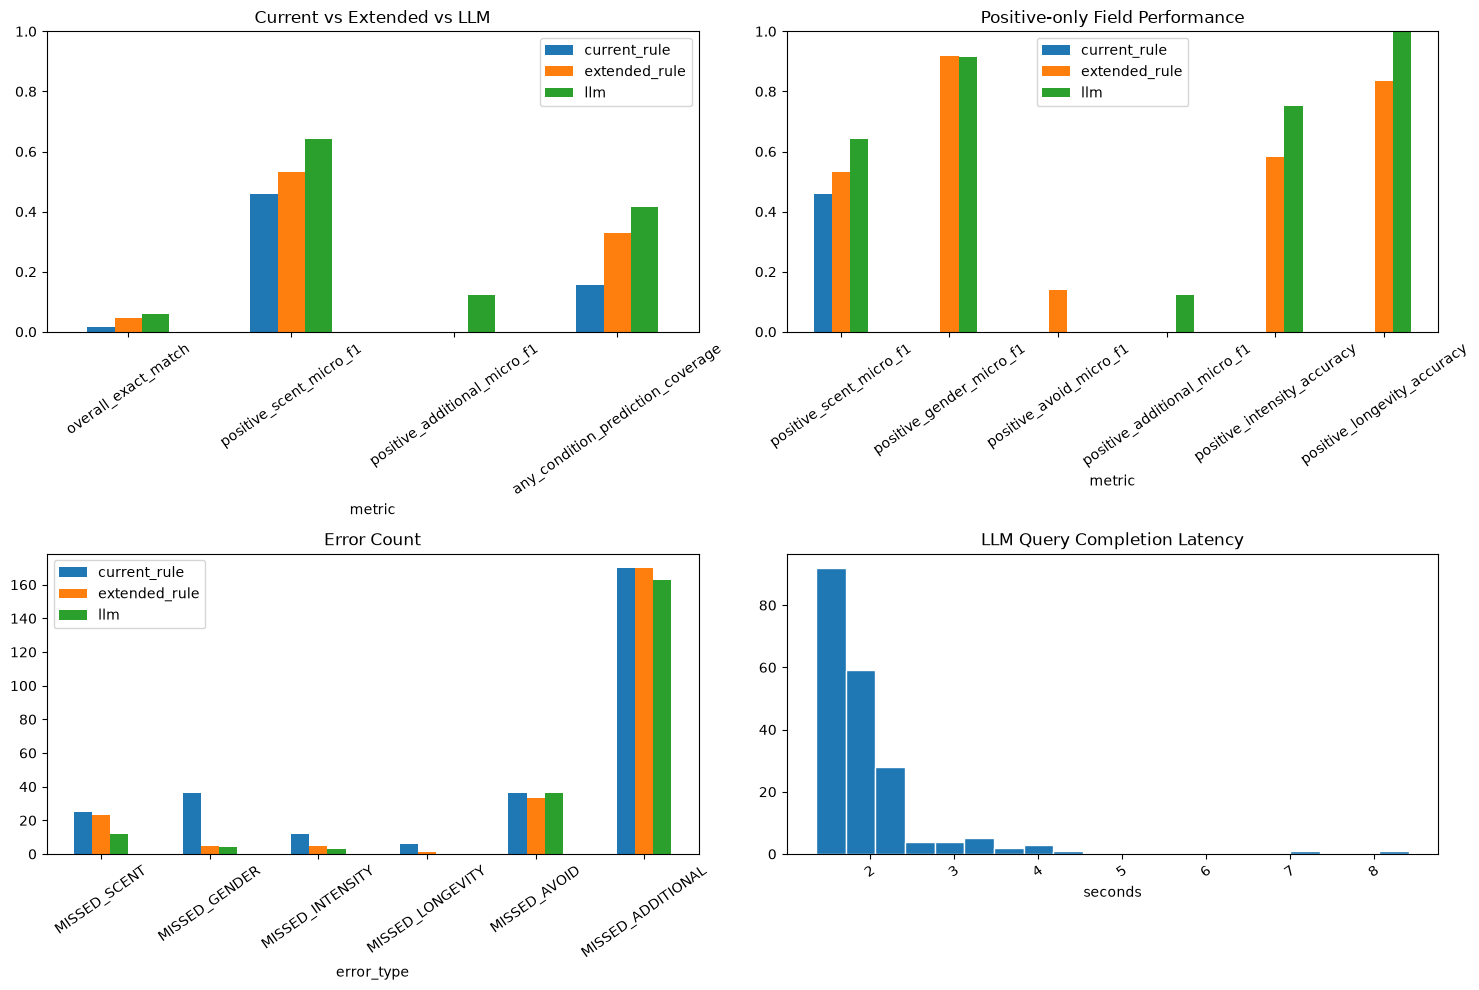

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
focus_plot = model_comparison_df[model_comparison_df.metric.isin(["overall_exact_match","any_condition_prediction_coverage","positive_scent_micro_f1","positive_additional_micro_f1"])].set_index("metric")
focus_plot[["current_rule","extended_rule","llm"]].plot(kind="bar", ax=axes[0,0], ylim=(0,1), title="Current vs Extended vs LLM")

field_plot_names = ["positive_scent_micro_f1","positive_gender_micro_f1","positive_avoid_micro_f1","positive_additional_micro_f1","positive_intensity_accuracy","positive_longevity_accuracy"]
field_plot = model_comparison_df[model_comparison_df.metric.isin(field_plot_names)].set_index("metric")
field_plot[["current_rule","extended_rule","llm"]].plot(kind="bar", ax=axes[0,1], ylim=(0,1), title="Positive-only Field Performance")

error_plot = error_comparison_df[error_comparison_df.error_type.isin(["MISSED_SCENT","MISSED_GENDER","MISSED_INTENSITY","MISSED_LONGEVITY","MISSED_AVOID","MISSED_ADDITIONAL"])].set_index("error_type")
error_plot[["current_rule","extended_rule","llm"]].plot(kind="bar", ax=axes[1,0], title="Error Count")
axes[1,1].hist(checkpoint_df.latency_seconds, bins=20, edgecolor="white")
axes[1,1].set_title("LLM Query Completion Latency")
axes[1,1].set_xlabel("seconds")
for ax in axes.flat: ax.tick_params(axis="x", rotation=35)
plt.tight_layout(); plt.show()


## 25. Save Outputs


In [25]:
prediction_output = predictions_df.copy()
for column in ["pred_scent_preference","pred_context","pred_performance","pred_avoid","pred_additional_requirements"]:
    prediction_output[column] = prediction_output[column].map(json_text)

def pct(value): return "N/A" if pd.isna(value) else f"{value:.2%}"
def sec(value): return "N/A" if pd.isna(value) else f"{value:.3f}s"
def token_text(value): return "N/A (usage 미제공)" if pd.isna(value) else f"{int(value):,}"
def comparison_markdown(metrics):
    lines=["| Metric | Current Rule | Extended Rule | LLM |","|---|---:|---:|---:|"]
    labels={
        "overall_exact_match":"Overall Exact Match","any_condition_prediction_coverage":"Coverage",
        "positive_scent_micro_f1":"Scent Positive F1","positive_gender_micro_f1":"Gender Positive F1",
        "positive_intensity_accuracy":"Intensity Positive Accuracy","positive_longevity_accuracy":"Longevity Positive Accuracy",
        "positive_avoid_micro_f1":"Avoid Positive F1","positive_additional_micro_f1":"Additional Positive F1",
    }
    indexed=metrics.set_index("metric")
    for name in focus_metrics:
        if name in indexed.index:
            row=indexed.loc[name]; lines.append(f"| {labels[name]} | {pct(row.current_rule)} | {pct(row.extended_rule)} | {pct(row.llm)} |")
    return "\n".join(lines)

regressed = query_changes_df[query_changes_df.change_type.eq("LLM_REGRESSED")]
regressed_lines = "\n".join(f"- {r.query_id}: {r.query_text}" for r in regressed.itertuples(index=False)) or "- 없음"
top_errors = error_comparison_df.sort_values("llm", ascending=False).head(10)
error_lines = "\n".join(f"- {r.error_type}: {r.llm}개" for r in top_errors.itertuples(index=False))
summary_text = f"""# Stage 1 LLM Evaluation

## 실험 목적

동일한 실제 사용자 자연어 200개에서 Current Rule, Extended Rule, GMS `gpt-5.4-nano`의 Stage 1 구조화 성능을 같은 정의로 비교했다. 향수 Ranking은 실행하지 않았다.

## 실험 환경

- Gateway: SSAFY GMS
- Model: {MODEL_NAME}
- Prompt Version: {PROMPT_VERSION}
- Prompt SHA256: {hashlib.sha256(STAGE1_DEVELOPER_PROMPT.encode('utf-8')).hexdigest()}
- Golden Set: 200개
- Run Timestamp: {RUN_TIMESTAMP}
- Retry: 최초 1회 + 최대 {MAX_RETRIES}회
- FORCE_RERUN: {FORCE_RERUN}

API Key는 기록하지 않았다.

## API 안정성

- 성공 Query: {int(api_metric_values['successful_queries'])}/200
- 실패 Query: {int(api_metric_values['failed_queries'])}/200
- First-attempt success rate: {pct(api_metric_values['first_attempt_success_rate'])}
- Retry Query / Total Retry: {int(api_metric_values['retry_query_count'])} / {int(api_metric_values['total_retry_count'])}
- API / JSON / Validation failure attempts: {int(api_metric_values['api_failure_count'])} / {int(api_metric_values['json_parse_failure_count'])} / {int(api_metric_values['schema_validation_failure_count'])}
- Mean / Median / p95 latency: {sec(api_metric_values['mean_latency'])} / {sec(api_metric_values['median_latency'])} / {sec(api_metric_values['p95_latency'])}
- Prompt / Completion / Total tokens: {token_text(api_metric_values['total_prompt_tokens'])} / {token_text(api_metric_values['total_completion_tokens'])} / {token_text(api_metric_values['total_tokens'])}

## LLM 성능

- Overall Exact Match: {pct(llm_metric['overall_exact_match'])}
- Coverage: {pct(llm_metric['any_condition_prediction_coverage'])}
- Scent Positive F1: {pct(llm_metric['positive_scent_micro_f1'])}
- Additional Positive F1: {pct(llm_metric['positive_additional_micro_f1'])}

## Current Rule vs Extended Rule vs LLM

{comparison_markdown(model_comparison_df)}

## Field별 비교

- Scent Positive F1: {pct(llm_metric['positive_scent_micro_f1'])}
- Gender Positive F1: {pct(llm_metric['positive_gender_micro_f1'])}
- Intensity Positive Accuracy: {pct(llm_metric['positive_intensity_accuracy'])}
- Longevity Positive Accuracy: {pct(llm_metric['positive_longevity_accuracy'])}
- Avoid Positive F1: {pct(llm_metric['positive_avoid_micro_f1'])}
- Additional Positive F1: {pct(llm_metric['positive_additional_micro_f1'])}

## 주요 개선

- LLM_FIXED: {int(change_counts.get('LLM_FIXED',0))}개
- Extended의 MISSED_ADDITIONAL {int(extended_component_counts.get('MISSED_ADDITIONAL',0))}개 대비 LLM은 {int(llm_component_counts.get('MISSED_ADDITIONAL',0))}개였다.

## LLM이 더 나빴던 Query

LLM_REGRESSED: {int(change_counts.get('LLM_REGRESSED',0))}개

{regressed_lines}

## 주요 오류

{error_lines}

`semantic_over_inference_candidate`는 자동 확정 판정이 아니라 사람이 검토할 후보 표시다.

## 비용 / 운영 관점

응답이 제공한 실제 Token Usage만 합산했다. 비용 단가가 제공되지 않아 금액 비용은 계산하지 않았다. Median은 가운데 Query 완료시간, p95는 95%의 Query가 그 시간 이하에 완료됐다는 뜻이다. Checkpoint와 resume으로 성공 Query 재호출을 방지한다.

## 결론

LLM의 상대 성능과 운영 특성은 위 실제 측정값으로 판단해야 한다. 특정 최종 방식을 결과와 무관하게 미리 확정하지 않는다.
"""

prediction_output.to_csv(PREDICTIONS_PATH,index=False,encoding="utf-8-sig")
evaluation_df.to_csv(EVALUATION_PATH,index=False,encoding="utf-8-sig")
errors_df.to_csv(ERRORS_PATH,index=False,encoding="utf-8-sig")
metrics_df.to_csv(METRICS_PATH,index=False,encoding="utf-8-sig")
api_metrics_df.to_csv(API_METRICS_PATH,index=False,encoding="utf-8-sig")
model_comparison_df.to_csv(MODEL_COMPARISON_PATH,index=False,encoding="utf-8-sig")
error_comparison_df.to_csv(ERROR_COMPARISON_PATH,index=False,encoding="utf-8-sig")
query_changes_df.to_csv(QUERY_CHANGES_PATH,index=False,encoding="utf-8-sig")
PROMPT_PATH.write_text(STAGE1_DEVELOPER_PROMPT,encoding="utf-8")
SUMMARY_PATH.write_text(summary_text,encoding="utf-8")

output_paths=[CHECKPOINT_PATH,PREDICTIONS_PATH,EVALUATION_PATH,ERRORS_PATH,METRICS_PATH,API_METRICS_PATH,MODEL_COMPARISON_PATH,ERROR_COMPARISON_PATH,QUERY_CHANGES_PATH,PROMPT_PATH,SUMMARY_PATH]
display(pd.DataFrame([{"file":p.name,"bytes":p.stat().st_size,"rows":len(pd.read_csv(p)) if p.suffix=='.csv' else np.nan} for p in output_paths]))


,file,bytes,rows
0,15_llm_stage1_checkpoint.csv,188712,200.0
1,15_llm_stage1_predictions.csv,126538,200.0
2,15_llm_stage1_evaluation.csv,100248,200.0
3,15_llm_stage1_errors.csv,95544,188.0
4,15_llm_stage1_metrics.csv,2379,66.0
5,15_llm_api_metrics.csv,551,19.0
6,15_stage1_model_comparison.csv,3220,62.0
7,15_error_comparison.csv,427,17.0
8,15_llm_vs_extended_query_changes.csv,21066,200.0
9,15_stage1_llm_prompt_v1.txt,2477,NaN


## 26. Final Summary


In [26]:
protected_hashes_after = {label: sha256_file(path) for label,path in PROTECTED_PATHS.items()}
if protected_hashes_before != protected_hashes_after:
    raise RuntimeError(f"보호 파일 변경 감지: {[k for k in protected_hashes_before if protected_hashes_before[k]!=protected_hashes_after[k]]}")
assert len(checkpoint_df)==len(prediction_output)==len(evaluation_df)==200
assert len(errors_df)==200-exact_match_count
assert prediction_output.query_id.nunique()==evaluation_df.query_id.nunique()==200
assert all(path.is_file() for path in output_paths)
assert PROMPT_PATH.read_text(encoding="utf-8")==STAGE1_DEVELOPER_PROMPT

final_api = pd.DataFrame({"Metric":["Total Queries","Successful","Failed","First-attempt Success Rate","Retry Queries","JSON Failures","Validation Failures","Mean Latency","Median Latency","P95 Latency","Total Tokens"],"Value":[api_metric_values[k] for k in ["total_queries","successful_queries","failed_queries","first_attempt_success_rate","retry_query_count","json_parse_failure_count","schema_validation_failure_count","mean_latency","median_latency","p95_latency","total_tokens"]]})
final_performance = model_comparison_df[model_comparison_df.metric.isin(focus_metrics)].copy()
final_changes = pd.DataFrame({"Change Type":["LLM_FIXED","BOTH_CORRECT","BOTH_WRONG","LLM_REGRESSED"],"Count":[int(change_counts.get(k,0)) for k in ["LLM_FIXED","BOTH_CORRECT","BOTH_WRONG","LLM_REGRESSED"]]})
display(Markdown("### [API]")); display(final_api)
display(Markdown("### [Stage 1 Performance]")); display(final_performance)
display(Markdown("### [Query Comparison]")); display(final_changes)
print("생성 파일:")
for path in output_paths: print("-", path.relative_to(PROJECT_ROOT))
print("보호 파일 해시 검증: 변경 없음")
print("Golden Set: 200개 / Predictions: 200행 / Evaluation: 200행")
print("GMS_KEY 출력 및 저장: 없음")


### [API]

,Metric,Value
0,Total Queries,200.000000
1,Successful,199.000000
2,Failed,1.000000
3,First-attempt Success Rate,0.990000
4,Retry Queries,2.000000
5,JSON Failures,0.000000
6,Validation Failures,4.000000
7,Mean Latency,1.960418
8,Median Latency,1.739377
9,P95 Latency,3.193674


### [Stage 1 Performance]

,metric,current_rule,extended_rule,llm
2,overall_exact_match,0.015000,0.045000,0.060000
36,positive_scent_micro_f1,0.459016,0.531250,0.641975
45,positive_gender_micro_f1,0.000000,0.918919,0.914286
49,positive_avoid_micro_f1,0.000000,0.137931,0.000000
53,positive_additional_micro_f1,0.000000,0.000000,0.123596
55,positive_intensity_accuracy,0.000000,0.583333,0.750000
57,positive_longevity_accuracy,0.000000,0.833333,1.000000
60,any_condition_prediction_coverage,0.155000,0.330000,0.415000


### [Query Comparison]

,Change Type,Count
0,LLM_FIXED,8
1,BOTH_CORRECT,4
2,BOTH_WRONG,183
3,LLM_REGRESSED,5


생성 파일:
- analysis_outputs\15_llm_stage1_checkpoint.csv
- analysis_outputs\15_llm_stage1_predictions.csv
- analysis_outputs\15_llm_stage1_evaluation.csv
- analysis_outputs\15_llm_stage1_errors.csv
- analysis_outputs\15_llm_stage1_metrics.csv
- analysis_outputs\15_llm_api_metrics.csv
- analysis_outputs\15_stage1_model_comparison.csv
- analysis_outputs\15_error_comparison.csv
- analysis_outputs\15_llm_vs_extended_query_changes.csv
- analysis_outputs\15_stage1_llm_prompt_v1.txt
- analysis_outputs\15_llm_stage1_summary.md
보호 파일 해시 검증: 변경 없음
Golden Set: 200개 / Predictions: 200행 / Evaluation: 200행
GMS_KEY 출력 및 저장: 없음
